### Задание

Самостоятельно напишите нейронную сеть, которая может стать составной частью системы бота для игры в "Крестики-нолики". Используя подготовленную базу изображений, создайте и обучите нейронную сеть, распознающую две категории изображений: крестики и нолики. Добейтесь точности распознавания более 95% (accuracy)


In [150]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import utils
from tensorflow.keras.preprocessing import image
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

%matplotlib inline

In [151]:
import gdown
url = 'https://drive.google.com/uc?id=1STlK6jwSU7NohjMlYBnlpiGlHh_N5fia'
gdown.download(url, 'hw_pro.zip', quiet=False)
!unzip -o -q hw_pro.zip
print("Готово")

Downloading...
From: https://drive.google.com/uc?id=1STlK6jwSU7NohjMlYBnlpiGlHh_N5fia
To: /content/hw_pro.zip
100%|██████████| 101k/101k [00:00<00:00, 3.33MB/s]

Готово


In [152]:
base_dir = '/content/hw_pro'
x_train, y_train = [], []
img_height, img_width = 20, 20

for patch in os.listdir(base_dir):
    patch_path = os.path.join(base_dir, patch)
    if os.path.isdir(patch_path):
        for img_file in os.listdir(patch_path):
            img = image.load_img(
                os.path.join(patch_path, img_file),
                target_size=(img_height, img_width),
                color_mode='grayscale'
            )
            x_train.append(image.img_to_array(img))

            if patch == '0':
                y_train.append(1)  # 1 = НОЛИК
            else:
                y_train.append(0)  # 0 = КРЕСТИК

x_train = np.array(x_train)
y_train = np.array(y_train)

print(f'Изображений: {x_train.shape}')
print(f'Меток: {y_train.shape}')
print(f'0 (КРЕСТИК): {np.sum(y_train==0)}')
print(f'1 (НОЛИК): {np.sum(y_train==1)}')

Изображений: (102, 20, 20, 1)
Меток: (102,)
0 (КРЕСТИК): 52
1 (НОЛИК): 50


In [153]:
CLASS_COUNT = 2

x_train = x_train.reshape(x_train.shape[0], -1)
x_train = x_train.astype('float32') / 255.
y_train_cat = utils.to_categorical(y_train, CLASS_COUNT)

print(f'x: {x_train.shape}, y: {y_train_cat.shape}')

x: (102, 400), y: (102, 2)


In [154]:
np.random.seed(42)
indices = np.random.permutation(len(x_train))
x_train = x_train[indices]
y_train_cat = y_train_cat[indices]

val_size = int(0.2 * len(x_train))
x_val = x_train[:val_size]
y_val = y_train_cat[:val_size]
x_train_split = x_train[val_size:]
y_train_split = y_train_cat[val_size:]

print(f'Train: {x_train_split.shape}, Val: {x_val.shape}')

Train: (82, 400), Val: (20, 400)


In [163]:
model = Sequential([
    Dense(54, input_dim=400, activation='relu'),
    Dropout(0.5),
    Dense(27, activation='relu'),
    Dropout(0.5),
    Dense(CLASS_COUNT, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    x_train_split, y_train_split,
    batch_size=32,
    epochs=50,
    validation_data=(x_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

test_loss, test_acc = model.evaluate(x_val, y_val, verbose=0)
print(f"Точность: {test_acc:.4f} ({test_acc*100:.1f}%)")

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 993ms/step - accuracy: 0.4783 - loss: 0.8832 - val_accuracy: 0.7000 - val_loss: 0.5481
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6643 - loss: 0.7046 - val_accuracy: 0.5500 - val_loss: 0.6601
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5500 - loss: 0.7589 - val_accuracy: 0.6000 - val_loss: 0.6378
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5644 - loss: 0.7507 - val_accuracy: 0.8500 - val_loss: 0.5765
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5656 - loss: 0.7036 - val_accuracy: 0.8500 - val_loss: 0.5914
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5212 - loss: 0.7041 - val_accuracy: 0.7000 - val_loss: 0.6261
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5874 - loss: 0.6750 - val_accuracy: 0.7500 - val_loss: 0.6301
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5978 - loss: 0.6547 - val_accuracy: 0.8500 - val_loss: 0.6013

In [167]:
model.save('xo_model_95.keras')

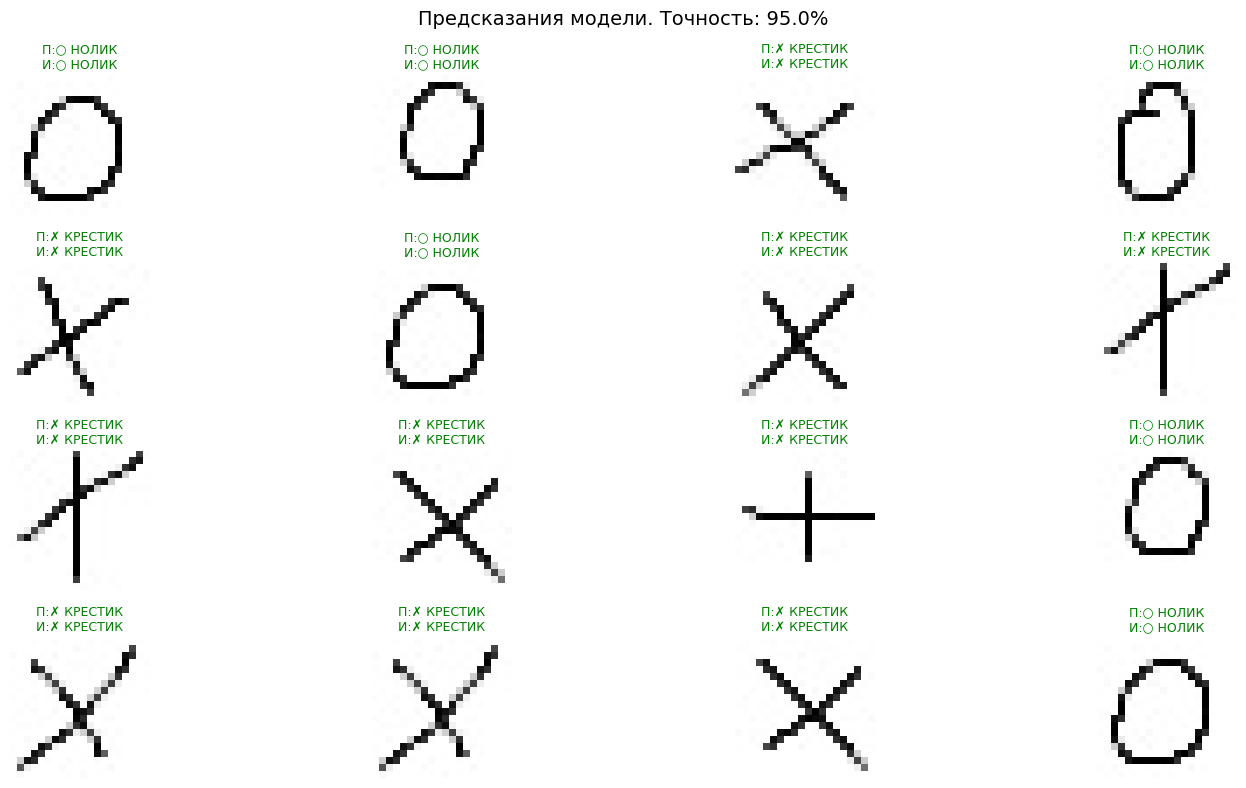

In [169]:
# Получаем предсказания
y_pred = model.predict(x_val, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

# Названия классов
class_names = ['✗ КРЕСТИК', '○ НОЛИК']

# Покажем 16 изображений
plt.figure(figsize=(16, 8))
for i in range(16):
    idx = np.random.randint(len(x_val))
    img = x_val[idx].reshape(20, 20)
    true = y_true_classes[idx]
    pred = y_pred_classes[idx]

    plt.subplot(4, 4, i+1)
    plt.imshow(img, cmap='gray')
    color = 'green' if pred == true else 'red'

    plt.title(f'П:{class_names[pred]}\nИ:{class_names[true]}',
              color=color, fontsize=9)
    plt.axis('off')

plt.suptitle(f'Предсказания модели. Точность: {test_acc*100:.1f}%', fontsize=14)
plt.tight_layout()
plt.show()